# Evaluting timing of the WEP pipeline on USDF

Owner: Bryce Kalmbach ([@jbkalmbach)](https://github.com/lsst-ts/ts_aos_analysis/issues/new?body=@jbkalmbach)

Last Verified to Run: 2024-08-22

Software Versions:
* `lsst_distrib`: **w_2024_32**

Requirements:
* `lsst_distrib`
* `ts_aos_analysis`

## Notebook Objective
This notebook calculates the timing to run the AOS Wavefront Estimation Pipeline (WEP).
We evaluate the timing based upon the information stored in the butler metadata as each task runs.

## Logistics
This notebook as written can be run on USDF using the AOS butler at `/sdf/data/rubin/repo/aos_imsim/`. 
You will need to change the repo directory if you want to access the timing of the pipeline in other USDF repos or on the summit. 
To do so change the `butler_path` and `collection_name` variables below accordingly.

## Imports

In [1]:
import numpy as np
from lsst.daf.butler import Butler
from astropy.time import Time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

In [2]:
from lsst.ts.aos.analysis import get_task_metadata, get_timing_from_metadata

In [3]:
from lsst.daf.butler import DatasetNotFoundError

## Load Test Data

In [4]:
butler_path = 'LSSTComCam'
collection_name = 'LSSTComCam/quickLook'
instrument = 'LSSTComCam'

Specify the exposures and detector IDs in the list below based upon the data and instrument upon which the pipeline ran.

In [5]:
butler = Butler(butler_path)
butler_records = butler.query_dimension_records('exposure', where="instrument = 'LSSTComCam' and exposure.observation_type = 'cwfs'")

In [6]:
group_exp_dict = dict()
for rec in butler_records:
    if rec.group in group_exp_dict.keys():
        group_exp_dict[rec.group].append(rec.id)
    else:
        group_exp_dict[rec.group] = [rec.id]

In [7]:
group_exp_dict_sorted = dict(sorted(group_exp_dict.items()))

In [8]:

# exposure_list = [2024120800553, 2024120800554]
detector_list = np.arange(9) # ComCam Detectors
# group_list = [butler.get(
#     'postISRCCD.metadata', 
#     dataId={'instrument': 'LSSTComCam', 'detector': 0, 'exposure': exp},
#     collections='LSSTComCam/quickLook'
# )['GROUPID'] for exp in exposure_list]

In [9]:
# If you ran the pipeline with additional aggregate and plotting tasks uncomment required tasks
task_list = [
    "isr",
    "generateDonutDirectDetectTask",
    # "aggregateDonutCatalogsTask",
    "cutOutDonutsScienceSensorGroupTask",
    # "aggregateDonutStampsTask",
    # "plotDonutTask",
    "calcZernikesTask",
    # "aggregateZernikesTask",
    # "aggregateAOSVisitTableTask",
    # "plotAOSTask",
]

In [10]:
# If you ran the pipeline with additional aggregate and plotting tasks uncomment required tasks
colors = {
    'isr': 'k',
    'generateDonutDirectDetectTask': 'r',
    # 'aggregateDonutCatalogsTask': 'g',
    'cutOutDonutsScienceSensorGroupTask': 'b',
    # 'aggregateDonutStampsTask': 'c',
    # 'plotDonutTask': 'm',
    'calcZernikesTask': 'y',
    # 'aggregateZernikesTask': 'orange',
    # 'aggregateAOSVisitTableTask': 'gray',
    # 'plotAOSTask': 'pink'
}

In [ ]:
full_timing_dict = dict()
for task in task_list:
    full_timing_dict[task] = []
for group, exposure_list in group_exp_dict_sorted.items():
    group_list = [group] * 2
    try:
        task_metadata = get_task_metadata(butler_path, collection_name, instrument, task_list, exposure_list, group_list, detector_list)
        jobs, first_job, last_job, longest_job_5_donuts = get_timing_from_metadata(task_metadata)
    except:
        print(group)
        continue
    for job in jobs:
        timing = (((Time(job[2][:-6]).mjd)) - ((Time(job[1][:-6]).mjd))) * 86400
        if timing <= 0:
            continue
        else:
            full_timing_dict[job[0]].append(timing)

In [11]:
import pickle

In [12]:
with open('comcam_onsky_timing.pickle', 'rb') as f:
    full_timing_dict = pickle.load(f)

([<matplotlib.axis.XTick at 0x7f09286c57d0>,
 [Text(0, 0, 'isr'),
  Text(1, 0, 'generateDonutDirectDetectTask'),
  Text(2, 0, 'cutOutDonutsScienceSensorGroupTask'),
  Text(3, 0, 'calcZernikesTask')])

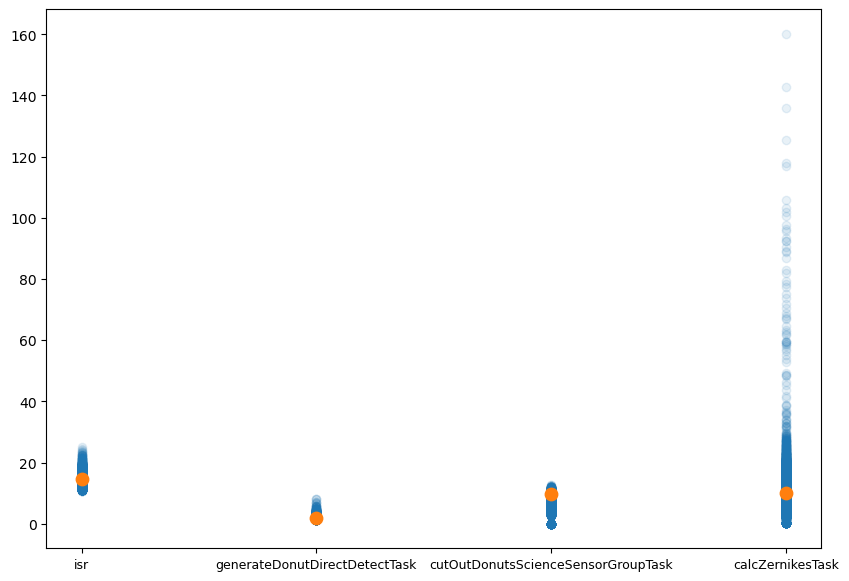

In [13]:
fig = plt.figure(figsize=(10, 7))
for i, task in enumerate(task_list):
    plt.scatter([i]*len(full_timing_dict[task]), full_timing_dict[task], alpha=0.1, c='C0')
    plt.scatter(i, np.median(full_timing_dict[task]), c='C1', s=80)
#    plt.errorbar(i, np.median(full_timing_dict[task]), yerr=np.std(full_timing_dict[task]), c='C1')
plt.xticks([0, 1, 2, 3], task_list, fontsize=9)

In [14]:
import seaborn as sbs
import pandas as pd

In [33]:
df = pd.DataFrame([], columns=['task_name', 'time'])
for task in task_list:
    df = pd.concat([df, pd.DataFrame(np.array([[task]*len(full_timing_dict[task]), np.array(full_timing_dict[task], dtype=float)]).T, columns=['task_name', 'time'])])

In [34]:
print(df)

              task_name                time
0                   isr  14.713426027446985
1                   isr  14.552027033641934
2                   isr   15.53736669011414
3                   isr  14.554535318166018
4                   isr  14.392158156260848
...                 ...                 ...
13087  calcZernikesTask   8.342201029881835
13088  calcZernikesTask   5.550375999882817
13089  calcZernikesTask   7.345450250431895
13090  calcZernikesTask    6.37534512206912
13091  calcZernikesTask   6.981039885431528

[92573 rows x 2 columns]


In [39]:
df['time'] = pd.to_numeric(df['time'])
print(df['time'])

0        14.713426
1        14.552027
2        15.537367
3        14.554535
4        14.392158
           ...    
13087     8.342201
13088     5.550376
13089     7.345450
13090     6.375345
13091     6.981040
Name: time, Length: 92573, dtype: float64


In [40]:
print(pd.DataFrame({
     'task_name': ['isr'] * 5 + ['calcZernikesTask'] * 5,
     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]
}))

          task_name   time
0               isr  14.71
1               isr  14.55
2               isr  15.53
3               isr  14.55
4               isr  14.39
5  calcZernikesTask   8.34
6  calcZernikesTask   5.55
7  calcZernikesTask   7.34
8  calcZernikesTask   6.37
9  calcZernikesTask   6.98


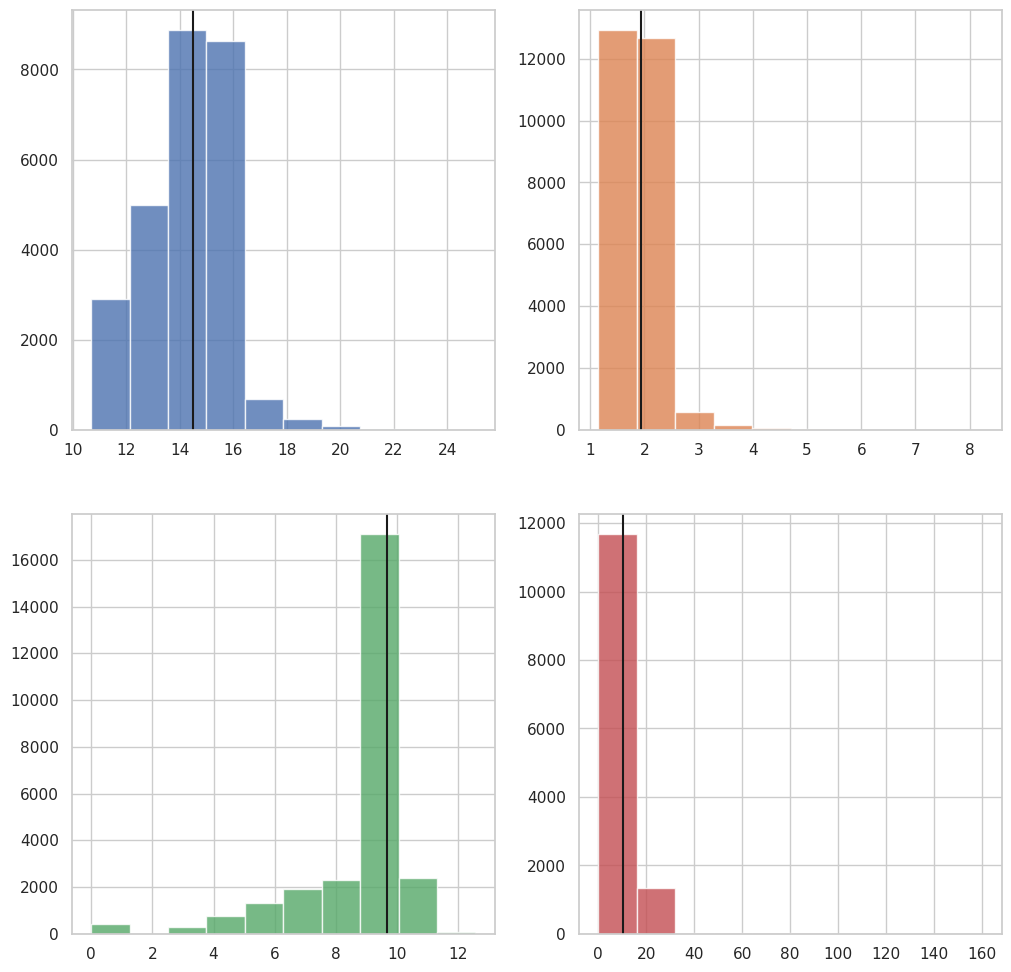

In [30]:
fig = plt.figure(figsize=(12, 12))
for i, task in enumerate(task_list):
    fig.add_subplot(2,2,i+1)
    plt.hist(full_timing_dict[task], alpha=0.8, color=f'C{i}')
    plt.axvline(np.median(full_timing_dict[task]), c='k')


<Axes: xlabel='time', ylabel='Density'>

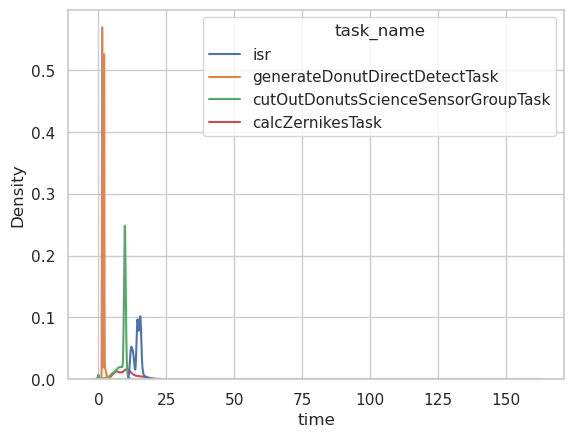

In [41]:
fig = plt.figure()
sns.kdeplot(data=df, x="time", hue="task_name")

/scratch/bkalmbach/tmp/ipykernel_10609/857051956.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")


task_name
calcZernikesTask                      10.217971
cutOutDonutsScienceSensorGroupTask     9.649746
generateDonutDirectDetectTask          1.934128
isr                                   14.502339
Name: time, dtype: float64


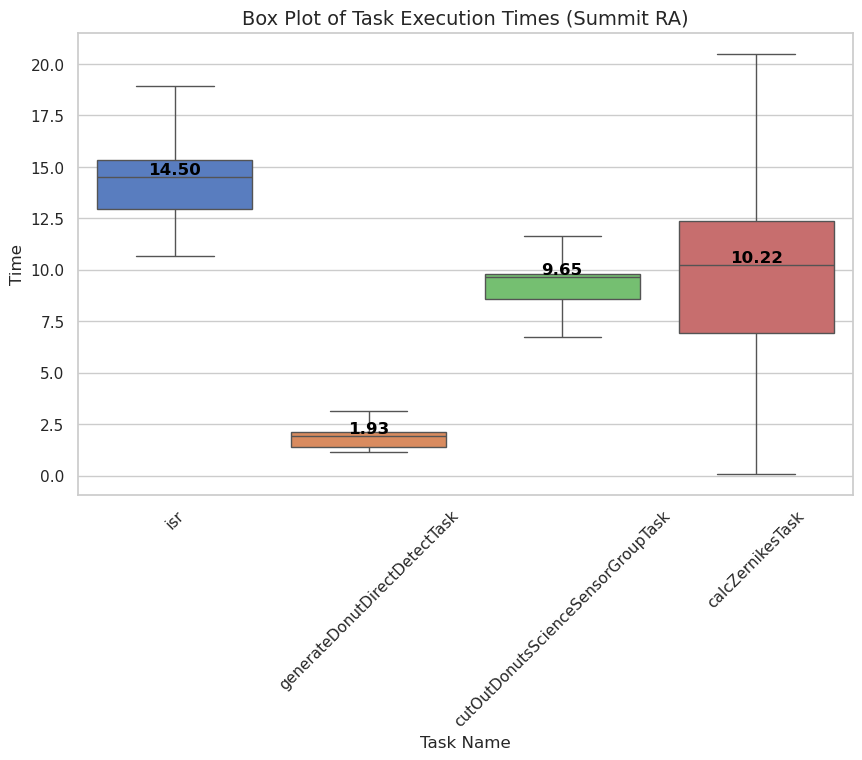

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Sample data (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'task_name': ['isr'] * 50 + ['calcZernikesTask'] * 50,
#     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]*10
# })

# Set the plot style
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")

# Customize labels and title
plt.xlabel('Task Name', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.title('Box Plot of Task Execution Times (Summit RA)', fontsize=14)
# ax.yaxis.grid(False)
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

# Calculate medians for each task
medians = df.groupby('task_name')['time'].median()
print(medians)
for i, task in enumerate(task_list):
    median_value = medians[task]
    ax.text(i, median_value, f'{median_value:.2f}', 
            horizontalalignment='center', 
            verticalalignment='bottom', 
            fontsize=12, fontweight='bold', color='black')

# Show the plot
plt.xticks(rotation=45)  # Rotate task names if necessary
plt.show()

In [ ]:
sbs.histplot(df, x='time')

<Axes: xlabel='time', ylabel='task_name'>

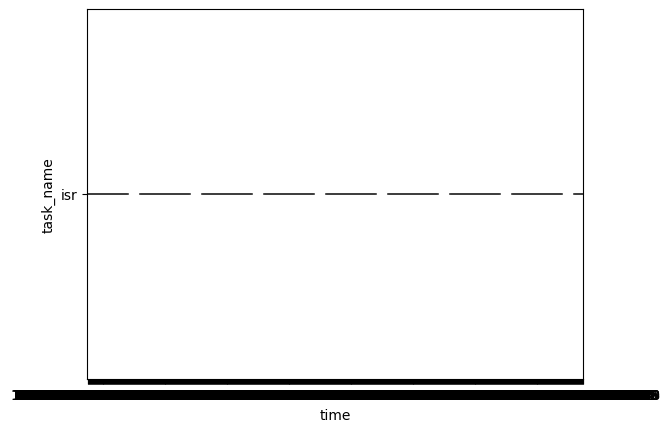

In [57]:
sbs.violinplot(df.iloc[:1000], x='time', y='task_name')

isr
generateDonutDirectDetectTask
cutOutDonutsScienceSensorGroupTask
calcZernikesTask


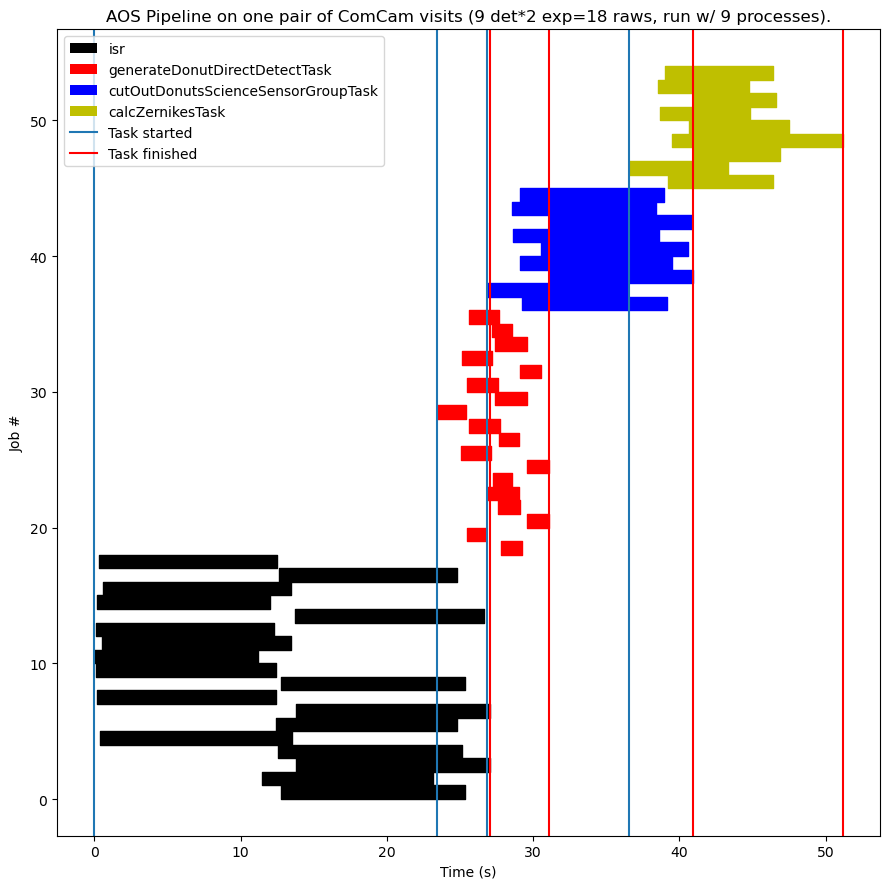

In [21]:
from matplotlib.lines import Line2D
task_metadata = get_task_metadata(butler_path, collection_name, instrument, task_list, exposure_list, group_list, detector_list)
jobs, first_job, last_job, longest_job_5_donuts = get_timing_from_metadata(task_metadata)
t0 = Time(min(j[1] for j in jobs)[:-6]).mjd

# Plot
plt.figure(figsize=(9,9))

start_list = []
ijob = -1
for job in jobs:
    start = (Time(job[1][:-6]).mjd-t0) * 86400
    end = (Time(job[2][:-6]).mjd-t0) * 86400
    if start in start_list:
        continue
    else:
        start_list.append(start)
        ijob += 1
    plt.fill_between([start, end], ijob, ijob+1, color=colors[job[0]])

# Create custom legend elements for both patches and lines
legend_elements = []
for k, v in colors.items():
    legend_elements.append(
        Patch(facecolor=v, label=k)
    )
# Add line elements to legend
legend_elements.append(Line2D([0], [0], color='C0', label='Task started'))
legend_elements.append(Line2D([0], [0], color='r', label='Task finished'))

# Calculate time between tasks
plt.axvline(0, color='C0')
plt.axvline((Time(last_job[-1][:-6]).mjd-t0) * 86400, color='r')
for first, last in zip(first_job[1:], last_job[:-1]):
    start = (Time(first[:-6]).mjd-t0) * 86400
    end = (Time(last[:-6]).mjd-t0) * 86400
    plt.axvline(start, color='C0')
    plt.axvline(end, color='r')
    #plt.text(end, 0.5, f'{(start-end):.2f}s', size=16, weight='bold')
    
# Add the legend to the plot
plt.legend(handles=legend_elements,)
plt.xlabel("Time (s)")
plt.ylabel("Job #")
plt.title('AOS Pipeline on one pair of ComCam visits (9 det*2 exp=18 raws, run w/ 9 processes).')
plt.tight_layout()

In [ ]:
fig = plt.figure()
t_start = 0
i = 0
for job_time, task in zip(longest_job_5_donuts, task_list):
    plt.fill_between([t_start, t_start+job_time], i, i+1, color=colors[task], label=task)
    t_start += job_time
    plt.text(t_start + 0.1, i+0.5, f"Max Time:\n {job_time:.2f}s")
    i += 1
plt.yticks([0.5, 1.5, 2.5, 3.5], ['ISR', 'Catalog\nCreation', 'Stamp\nGeneration', 'Zernike\nEstimation\n(5 Sources)'], size=9)
plt.legend()
plt.xlabel('Time (sec)')
plt.title('Expected Maximum Runtime per Task Type')

In [16]:
# with open('comcam_onsky_timing.pickle', 'wb') as handle:
#     pickle.dump(full_timing_dict, handle)